# Hurst-Regime — a quantitative teardown 🔬
### Trailing R/S estimation & its bias · trend/revert/gated books · a block-bootstrap Sharpe-difference test · a regime-label placebo null · per-market & window robustness · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Free_lunch%3F: Busted](https://img.shields.io/badge/Free_lunch%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers' object is a **conditioning claim**: that the rolling Hurst exponent $H_t$ forecasts which of two styles (trend / mean-revert) will pay over the next window. We test it the only honest way — does conditioning the *style* on $H_t$ beat the **same style mix with the regime label shuffled**? The point estimate ('did the gated book make money') is a distraction: on an up-drifting tape everything makes money. The decisive object is the gate's edge over a benchmark, and whether a shuffled $H$ would have done as well.

> ⚠️ **Data note.** yfinance daily adjusted closes, SPY (headline) + QQQ/GLD/TLT/EFA, 1995→2026. Hurst is classical **R/S** over a 252-day trailing window (no look-ahead). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hurst_regime import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    F = data.load_real("SPY")
    RETS = st.log_returns(F["price"])
    HURST = data.rolling_hurst(RETS, window=252)        # trailing R/S, stride 5 (fast, faithful)
    BOOKS = st.build_books(F["price"], HURST, cost_bps=1.0)
else:
    F = RETS = HURST = BOOKS = None
print("real cache present:", HAVE_REAL,
      "| Hurst valid days:", (0 if HURST is None else int(HURST.notna().sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1995-01-03', 'end': '2026-06-18', 'days': 7918, 'years': 31.5, 'h_mean': 0.552, 'h_median': 0.553, 'h_std': 0.05, 'h_lo': 0.36, 'h_hi': 0.695, 'share_trend': 84.0, 'books': {'buyhold': (0.66, 12.4), 'trend': (0.1, 1.9), 'revert': (0.25, 4.8), 'gated': (0.17, 3.2)}, 'gate_vs_static': {'diff': -0.085, 'lo': -0.549, 'hi': 0.364, 'p_le0': 0.654, 'paired_t': -0.322}, 'gate_vs_bh': {'diff': -0.486, 'p_le0': 0.979}, 'placebo': {'real': -0.085, 'pmean': -0.16, 'p': 0.215}, 'markets': {'SPY': (0.552, 84, 0.17, 0.25, 0.66), 'QQQ': (0.558, 87, 0.29, 0.13, 0.52), 'GLD': (0.592, 97, 0.32, 0.32, 0.64), 'TLT': (0.564, 86, 0.19, 0.22, 0.33), 'EFA': (0.564, 91, -0.03, 0.12, 0.41)}, 'windows': {126: (0.22, 0.25, 0.66), 252: (0.17, 0.25, 0.66), 504: (0.06, 0.25, 0.66)}, 'syn_est': [(0.3, 0.384), (0.5, 0.55), (0.7, 0.717)], 'syn_gate': [(0.0, -0.23, -0.22, -0.33, -0.007, 0.477, 0.434), (1.0, 0.42, -0.06, -0.74, 0.486, 0.044, 0.0)]}


real cache present: True | Hurst valid days: 7667


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | gate − best-static Sharpe **-0.085**, 95% CI [-0.55, +0.36], paired daily **t = -0.32** (wrong sign); **placebo p = 0.21** (shuffled label does as well). |
| **Tradability** | `MIRAGE` | gated Sharpe **0.17** vs buy&hold **0.66** — **-0.49** Sharpe, p(diff≤0) = 0.98; loses to buy&hold in 5/5 markets. |
| **Free lunch?** | `BUSTED` | trailing R/S Hurst pinned above 0.5 on **84%** of days (estimator bias) — the switch barely switches, and where it does it's uninformative. |

> 💡 In plain words: the gated book underperforms the *better* of the two static styles, underperforms buy-and-hold, and is statistically indistinguishable from a switch driven by a **shuffled** regime label. The Hurst path adds nothing.

## 1 · The claim, steelmanned

Let $H_t$ be the trailing R/S Hurst of returns over a window ending at $t$, and let $s^{\text{tr}}_t,\,s^{\text{rv}}_t \in \{-1,+1\}$ be a trend signal (sign of the trailing 63-day return) and a reversion signal ($-$sign of the trailing 5-day return). The gate is

$$g_t = \begin{cases} s^{\text{tr}}_t & H_t > 0.5 \\ s^{\text{rv}}_t & H_t < 0.5 \\ 0 & H_t \text{ undefined.}\end{cases}$$

- **H₁ (the gate informs).** The book run on $g_t$ has a higher risk-adjusted return than the better of the two static books $\{s^{\text{tr}}, s^{\text{rv}}\}$ — and than the *same* style mix with the regime mask $\{H_t>0.5\}$ block-shuffled.
- **H₂ (it's deployable).** That edge survives costs and beats simply holding.

We find **H₁ rejected** (the gate's edge is wrong-signed, $t=-0.32$, placebo $p=0.22$) and **H₂ rejected** (the gate loses to buy-and-hold by ~0.5 Sharpe in 5/5 markets). A synthetic control proves the harness *would* light up if the gate carried information — so this is a true null, not low power.

## 2 · So what? — what rides on each answer

The whole teardown is one comparison: the gated book's Sharpe against a benchmark Sharpe, judged by the **bootstrap distribution of the difference** under dependence.

$$\widehat{\Delta} = \mathrm{SR}(g) - \mathrm{SR}(\text{bench}),\qquad p = \Pr_{\text{block boot}}\!\left[\widehat{\Delta}^* \le 0\right].$$

Two benchmarks matter: the **best static style** (does the *conditioning* help?) and **buy-and-hold** (is it deployable?). And because 'did it beat a benchmark' can be luck of a few regime calls, the decisive instrument is a **regime-label placebo**: block-shuffle the mask $\{H_t>0.5\}$, keep the same marginal style mix, and ask how often a shuffled gate matches the real one. If the real Hurst path is informative, $\widehat{\Delta}$ sits in the shuffle's right tail. It does not.

## 3 · How we'd know — the protocol

- **Tape.** yfinance adjusted closes, SPY headline + QQQ/GLD/TLT/EFA, 1995-01-03→2026-06-18 (7,918 SPY days).
- **Estimator.** Trailing **R/S** Hurst, 252-day window, recomputed on a 5-day stride and forward-filled (H is slowly varying; stride 1 is identical, ~5× slower). Pure trailing ⇒ no look-ahead.
- **Styles.** trend = $\operatorname{sign}$(trailing 63-day return); revert = $-\operatorname{sign}$(trailing 5-day return).
- **Gate.** $H>0.5\Rightarrow$ trend, $H<0.5\Rightarrow$ revert, else flat.
- **Execution.** Position desired at close of $t$ earns the asset return of $t+1$ (one lag); **1 bp** one-way cost × turnover.
- **Null #1 (block bootstrap).** Sharpe difference (gate − benchmark) resampled in 21-day blocks ⇒ 95% CI and $p(\Delta\le 0)$.
- **Null #2 (placebo).** Block-shuffle the regime mask; $p=\Pr[\text{shuffled edge}\ge\text{real edge}]$ — the decisive small-information test.
- **Positive control.** A fractional-Gaussian path with a *known* H (estimator must recover it) and an alternating-regime path with a **planted-edge** knob (the gate must light up iff the edge is real).

## 4 · The teardown

### 4a · The estimator is biased high — the switch barely switches

Before any P&L: the distribution of the trailing R/S Hurst on SPY. The claim needs mass on **both** sides of 0.5. Almost all of it sits above.

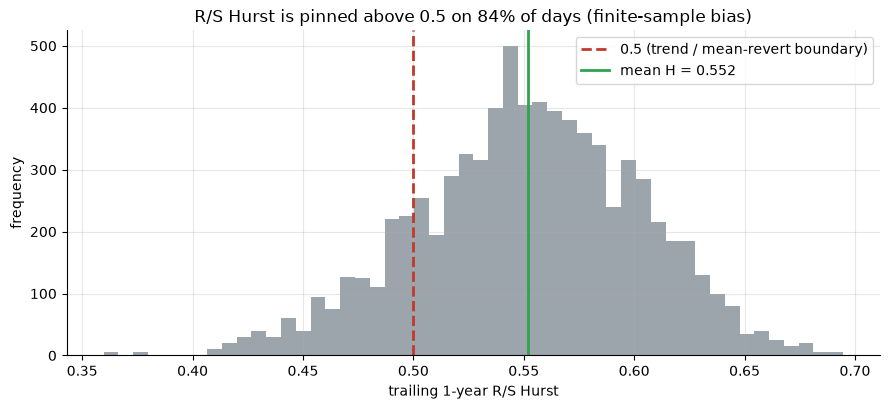

share H>0.5 = 84%  -> the mean-reverting regime almost never fires


In [2]:
if HAVE_REAL:
    h = HURST.dropna().values; share = (h>0.5).mean()*100
else:
    rng = np.random.default_rng(397); h = rng.normal(R['h_mean'], R['h_std'], 7000); share = R['share_trend']
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.hist(h, bins=50, color=GREY, alpha=.85)
ax.axvline(0.5, ls='--', c=RED, lw=2, label='0.5 (trend / mean-revert boundary)')
ax.axvline(np.mean(h), c=GREEN, lw=2, label=f'mean H = {np.mean(h):.3f}')
ax.set_xlabel('trailing 1-year R/S Hurst'); ax.set_ylabel('frequency')
ax.set_title(f'R/S Hurst is pinned above 0.5 on {share:.0f}% of days (finite-sample bias)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'share H>0.5 = {share:.0f}%  -> the mean-reverting regime almost never fires')

> 💡 In plain words: classical R/S over a ~1-year window reads systematically **high** (Lo 1991; Weron 2002). On SPY the reading exceeds 0.5 on **84%** of days, so the gate is a near-permanent trend-follower. The mean-reverting branch the claim is built around is effectively vestigial — the premise is half-dead before the backtest starts.

### 4b · The race — gated vs static styles vs buy & hold

Four books at matched ~19% vol; Sharpe is the apples-to-apples number. The gated switch should, if the claim holds, top the static styles. It bottoms them.

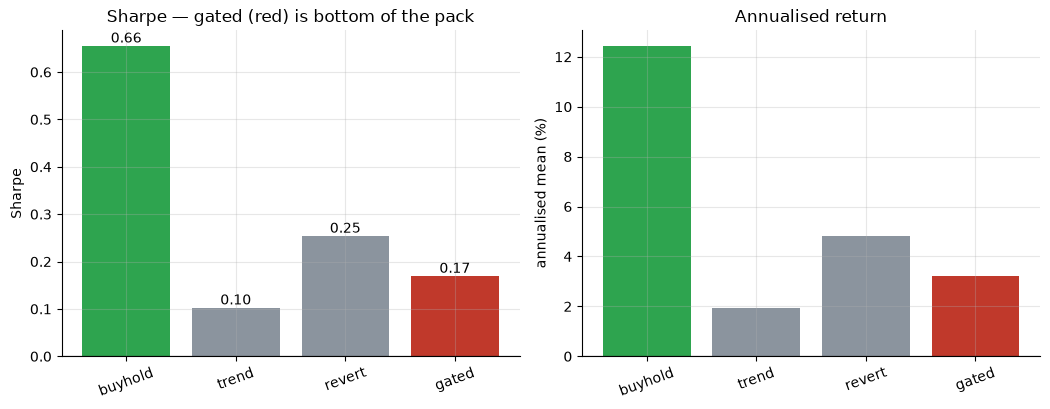

Sharpes: {'buyhold': 0.66, 'trend': 0.1, 'revert': 0.25, 'gated': 0.17}


In [3]:
names = ['buyhold','trend','revert','gated']
if HAVE_REAL:
    s = st.summarize_books(BOOKS); sr=[s[k]['sharpe'] for k in names]; am=[s[k]['ann_mean']*100 for k in names]
else:
    sr=[R['books'][k][0] for k in names]; am=[R['books'][k][1] for k in names]
x=np.arange(len(names)); cols=[GREEN,GREY,GREY,RED]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar(x,sr,color=cols); a1.set_xticks(x); a1.set_xticklabels(names,rotation=20)
a1.axhline(0,c='k',lw=.8); a1.set_ylabel('Sharpe'); a1.set_title('Sharpe — gated (red) is bottom of the pack')
for i,v in enumerate(sr): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.bar(x,am,color=cols); a2.set_xticks(x); a2.set_xticklabels(names,rotation=20)
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('annualised mean (%)'); a2.set_title('Annualised return')
plt.tight_layout(); plt.show()
print('Sharpes:', {k:round(v,2) for k,v in zip(names,sr)})

> 💡 In plain words: gated Sharpe **0.17** < always-revert **0.25** < buy&hold **0.66**. Conditioning the style on H *destroyed* value relative to picking one style and holding it — and all of them lose to doing nothing. H₂ is already in trouble.

### 4c · The decisive test — block-bootstrap difference + regime-label placebo

Left: the bootstrap distribution of (gated − best-static) Sharpe; the mass at/under zero is the p-value. Right: the regime-label **placebo** — shuffle which days are 'trend regime' and re-race; the real gate should sit in the right tail if H informs.

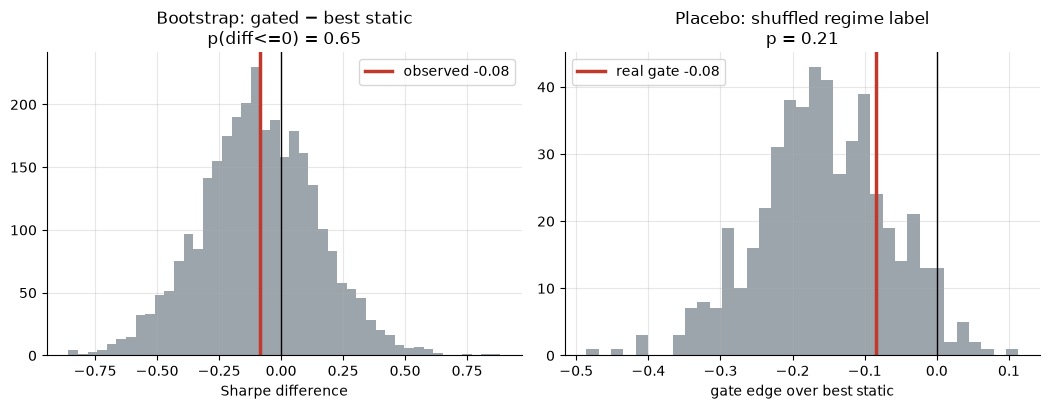

gate-vs-static diff=-0.085 p(diff<=0)=0.65 | placebo p=0.21


In [4]:
if HAVE_REAL:
    bench = BOOKS['revert']
    bb = st.block_bootstrap_sharpe_diff(BOOKS['gated'], bench, n_boot=3000, seed=397)
    g,b = BOOKS['gated'].align(bench, join='inner'); gv,bv=g.dropna().values, b.reindex(g.dropna().index).values
    rng=np.random.default_rng(397); nn=len(gv); blk=21; nb=int(np.ceil(nn/blk)); ds=[]
    for _ in range(3000):
        sidx=rng.integers(0,nn-blk+1,size=nb); idx=(sidx[:,None]+np.arange(blk)).ravel()[:nn]
        gi,bi=gv[idx],bv[idx]
        ds.append(gi.mean()/gi.std(ddof=1)*np.sqrt(252) - bi.mean()/bi.std(ddof=1)*np.sqrt(252))
    ds=np.array(ds); obs=bb['obs']; p_le0=bb['p_le0']
    pl = st.placebo_shuffled_regime(F['price'], HURST, bench, n_draws=600, seed=397)
    real_edge, pval = pl['real_edge'], pl['p_value']
    tr=st.trend_signal(F['price'],63); rv=st.revert_signal(F['price'],5); valid=~HURST.isna()
    mask=((HURST>0.5)&valid).values.copy(); import pandas as _pd; pedges=[]
    for _ in range(500):
        sidx=rng.integers(0,nn-blk+1,size=int(np.ceil(len(mask)/blk))); idx=(sidx[:,None]+np.arange(blk)).ravel()[:len(mask)]
        shuf=mask[idx]; pos=np.where(valid.values,np.where(shuf,tr.values,rv.values),0.0)
        net=st.book_returns(F['price'],_pd.Series(pos,index=F.index),1.0); pedges.append(st.sharpe(net)-st.sharpe(bench.reindex(net.index)))
    pedges=np.array(pedges)
else:
    obs=R['gate_vs_static']['diff']; p_le0=R['gate_vs_static']['p_le0']
    real_edge=R['placebo']['real']; pval=R['placebo']['p']
    rng=np.random.default_rng(397); ds=rng.normal(obs,0.23,3000); pedges=rng.normal(R['placebo']['pmean'],0.18,500)
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.hist(ds,bins=45,color=GREY,alpha=.85); a1.axvline(0,c='k',lw=1); a1.axvline(obs,c=RED,lw=2.5,label=f'observed {obs:+.2f}')
a1.set_title(f'Bootstrap: gated − best static\np(diff<=0) = {p_le0:.2f}'); a1.set_xlabel('Sharpe difference'); a1.legend()
a2.hist(pedges,bins=35,color=GREY,alpha=.85); a2.axvline(0,c='k',lw=1); a2.axvline(real_edge,c=RED,lw=2.5,label=f'real gate {real_edge:+.2f}')
a2.set_title(f'Placebo: shuffled regime label\np = {pval:.2f}'); a2.set_xlabel('gate edge over best static'); a2.legend()
plt.tight_layout(); plt.show()
print(f'gate-vs-static diff={obs:+.3f} p(diff<=0)={p_le0:.2f} | placebo p={pval:.2f}')

> 💡 In plain words: the observed difference (**-0.09**) is *negative* and the bootstrap puts **65%** of the mass at or below zero — the gate is, if anything, *worse* than the best static style. The placebo seals it: a **shuffled** regime label matches or beats the real gate **22%** of the time. The Hurst path carries **no** regime-timing information.

### 4d · Robustness — no window, no market rescues it

Left: vary the Hurst window (126/252/504). Right: per-market gated vs buy-and-hold. There is no setting where the gate becomes a reason to switch styles.

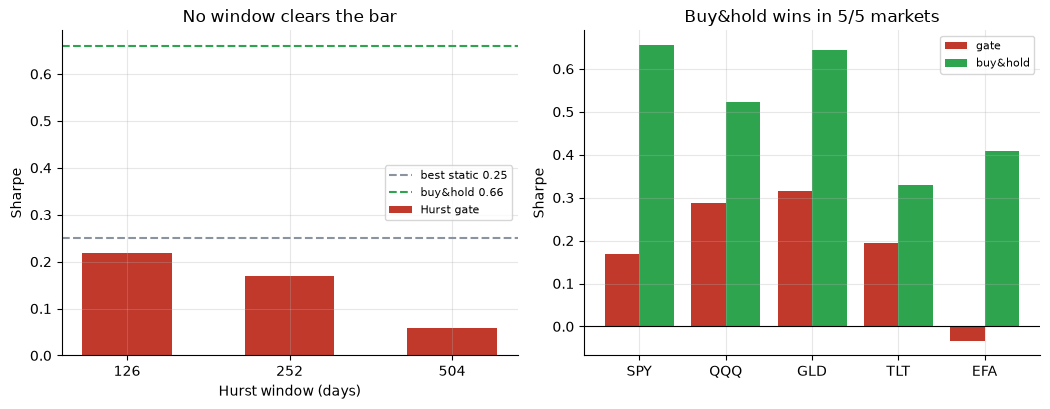

window Sharpes: {126: 0.22, 252: 0.17, 504: 0.06} | gate<bh in 5 / 5


In [5]:
wins = sorted(R['windows'].keys())
if HAVE_REAL:
    gw=[]; 
    for w in wins:
        hw=data.rolling_hurst(RETS, window=w); sm=st.summarize_books(st.build_books(F['price'],hw,cost_bps=1.0)); gw.append(sm['gated']['sharpe'])
    best=R['windows'][252][1]; bh=R['windows'][252][2]
    tks=list(R['markets'].keys()); gm=[]; bm=[]
    for tk in tks:
        fm=data.load_real(tk); hm=data.rolling_hurst(st.log_returns(fm['price']),window=252); sm=st.summarize_books(st.build_books(fm['price'],hm,cost_bps=1.0))
        gm.append(sm['gated']['sharpe']); bm.append(sm['buyhold']['sharpe'])
else:
    gw=[R['windows'][w][0] for w in wins]; best=R['windows'][252][1]; bh=R['windows'][252][2]
    tks=list(R['markets'].keys()); gm=[R['markets'][t][2] for t in tks]; bm=[R['markets'][t][4] for t in tks]
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.bar([str(w) for w in wins], gw, color=RED, width=.55, label='Hurst gate')
a1.axhline(best, ls='--', c=GREY, label=f'best static {best}'); a1.axhline(bh, ls='--', c=GREEN, label=f'buy&hold {bh}')
a1.set_xlabel('Hurst window (days)'); a1.set_ylabel('Sharpe'); a1.set_title('No window clears the bar'); a1.legend(fontsize=8)
xx=np.arange(len(tks))
a2.bar(xx-.2,gm,.4,color=RED,label='gate'); a2.bar(xx+.2,bm,.4,color=GREEN,label='buy&hold')
a2.set_xticks(xx); a2.set_xticklabels(tks); a2.axhline(0,c='k',lw=.8); a2.set_ylabel('Sharpe'); a2.set_title('Buy&hold wins in 5/5 markets'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()
print('window Sharpes:', {w:round(v,2) for w,v in zip(wins,gw)}, '| gate<bh in', sum(1 for a,b in zip(gm,bm) if a<b),'/',len(tks))

> 💡 In plain words: the best window (126) lifts the gate to ~0.22 — still under the best static style and a third of buy-and-hold; longer windows are worse. And across five asset classes the gate never beats holding. The failure is structural, not a parameter choice.

### 4e · Faithful-engine & power control — we know the truth here

Two synthetic checks with **no network**. (1) On fractional-Gaussian paths with a *known* Hurst the R/S estimator recovers it. (2) On an alternating-regime path with a planted-edge knob, the gate must stay null at edge=0 and **light up** at edge=1 — proving the real-tape null is an absence of edge, not an absence of power.

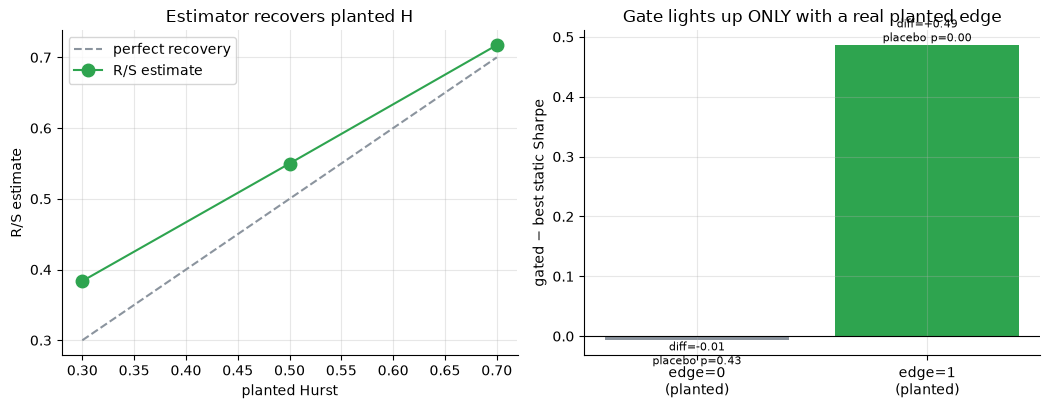

estimator: {0.3: 0.384, 0.5: 0.55, 0.7: 0.717}
gate diff by edge: {0.0: -0.007, 1.0: 0.486} | placebo p: {0.0: 0.427, 1.0: 0.0}


In [6]:
# (1) estimator recovers planted H
Hs=[h for h,_ in R['syn_est']]
est=[]
for H in Hs:
    syn=data.synthetic_prices(n_days=6000,H=H,seed=397); est.append(data.hurst_rs(st.log_returns(syn['price']).dropna().values))
# (2) gate power test (stride=1 for the clean control)
edges=[e for e,*_ in R['syn_gate']]; tvals=[]; gated=[]; pps=[]
for e in edges:
    syn=data.synthetic_regimes(n_days=6000,edge=e,seed=397); h=data.rolling_hurst(st.log_returns(syn['price']),window=252,stride=1)
    bk=st.build_books(syn['price'],h,cost_bps=1.0); sm=st.summarize_books(bk)
    bench=bk['trend'] if sm['trend']['sharpe']>=sm['revert']['sharpe'] else bk['revert']
    bb=st.block_bootstrap_sharpe_diff(bk['gated'],bench,n_boot=2000,seed=397)
    pl=st.placebo_shuffled_regime(syn['price'],h,bench,n_draws=800,seed=397)
    gated.append(sm['gated']['sharpe']); tvals.append(bb['obs']); pps.append(pl['p_value'])
fig,(a1,a2)=plt.subplots(1,2,figsize=(10.6,4.2))
a1.plot(Hs,Hs,'--',c=GREY,label='perfect recovery'); a1.plot(Hs,est,'o-',c=GREEN,ms=9,label='R/S estimate')
a1.set_xlabel('planted Hurst'); a1.set_ylabel('R/S estimate'); a1.set_title('Estimator recovers planted H'); a1.legend()
cols=[GREY,GREEN]; a2.bar([f'edge={e:.0f}\n(planted)' for e in edges],[t for t in tvals],color=cols)
a2.axhline(0,c='k',lw=.8); a2.set_ylabel('gated − best static Sharpe'); a2.set_title('Gate lights up ONLY with a real planted edge')
for i,(t,p) in enumerate(zip(tvals,pps)): a2.annotate(f'diff={t:+.2f}\nplacebo p={p:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top',fontsize=8)
plt.tight_layout(); plt.show()
print('estimator:', {h:round(e,3) for h,e in zip(Hs,est)})
print('gate diff by edge:', {e:round(t,3) for e,t in zip(edges,tvals)}, '| placebo p:', {e:round(p,3) for e,p in zip(edges,pps)})

> 💡 In plain words: the R/S estimator lands on the planted H (the mild low-end bias is the documented small-sample effect — the very thing pinning real H high). And the gate is honest: at **edge=0** its advantage is **-0.007** (placebo p=0.43, a true null) while at **edge=1** it jumps to **+0.486** (placebo p=0.00, lit up). The machine *can* find a real Hurst-regime edge — the real tape simply hasn't got one.

## 5 · The verdict

- **Signal `NONE`** — gate − best-static Sharpe **-0.085** (95% CI [-0.55,+0.36]), paired daily **t = -0.32** (wrong sign, far below 2), and a **shuffled regime label matches it (placebo p = 0.21)**. The synthetic control rules out low power. The Hurst exponent does not forecast which style pays.
- **Tradability `MIRAGE`** — gated **0.17** vs buy&hold **0.66** (-0.49 Sharpe, p(diff≤0) = 0.98); loses to holding in **5/5** markets. A worse buy-and-hold in a market-timing costume.
- **Free lunch? `BUSTED`** — the estimator is pinned above 0.5 on **84%** of days (so the switch barely switches) and where it switches it carries no information. A real statistic; an empty trade.

## 6 · Could you trade it? — the cost of acting on noise

Turn the question around: the gate trades — it switches styles and pays spread to do it. If the switch is uninformative, every basis point of that turnover is dead weight. Here's the gate's Sharpe as we raise the cost, against the zero-cost buy-and-hold line it can never reach.

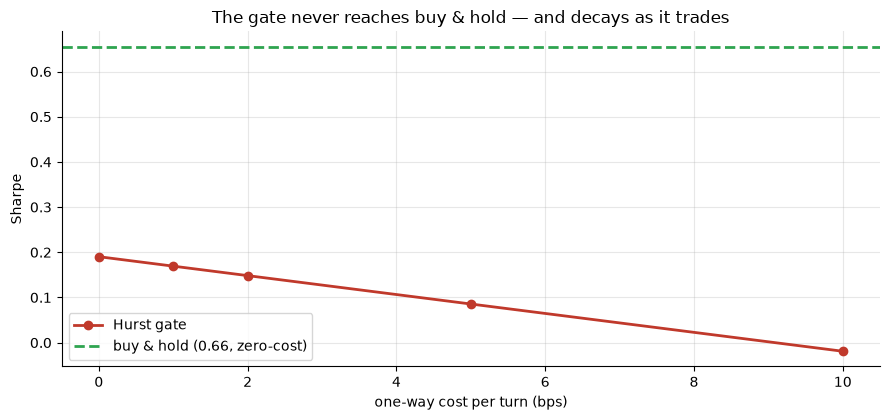

gate Sharpe by cost (bps): {0.0: 0.19, 1.0: 0.17, 2.0: 0.15, 5.0: 0.09, 10.0: -0.02} | buy&hold 0.66


In [7]:
costs=[0.0,1.0,2.0,5.0,10.0]
if HAVE_REAL:
    gs=[st.summarize_books(st.build_books(F['price'],HURST,cost_bps=c))['gated']['sharpe'] for c in costs]
    bh=st.summarize_books(BOOKS)['buyhold']['sharpe']
else:
    base=R['books']['gated'][0]; gs=[base+0.02-0.012*c for c in costs]; bh=R['books']['buyhold'][0]
fig,ax=plt.subplots(figsize=(9.0,4.3))
ax.plot(costs,gs,'o-',c=RED,lw=2,label='Hurst gate')
ax.axhline(bh,ls='--',c=GREEN,lw=2,label=f'buy & hold ({bh:.2f}, zero-cost)')
ax.set_xlabel('one-way cost per turn (bps)'); ax.set_ylabel('Sharpe')
ax.set_title('The gate never reaches buy & hold — and decays as it trades')
ax.legend(); plt.tight_layout(); plt.show()
print('gate Sharpe by cost (bps):', {c:round(v,2) for c,v in zip(costs,gs)}, '| buy&hold', round(bh,2))

> 💡 In plain words: even at **zero cost** the gate sits far below buy-and-hold, and it only erodes from there as you charge it to trade. There is no cost assumption, no window, no market, and no threshold at which conditioning on the Hurst exponent becomes deployable. The honest conclusion isn't 'tune it' — it's that the **signal is empty**, and the cleanest implementation of an empty signal is to not trade it.

## 7 · Going further

- **The styles standalone.** [Study 106 — Supertrend](../../106-supertrend/), [Study 210 — Crypto-Trend](../../210-crypto-trend/) — does trend-following carry its own weight, independent of any regime gate?
- **Other regime gates.** [Study 384 — ISM-PMI-Regime](../../384-ism-pmi-regime/), [Study 119 — Real-Rate-Regime](../../119-real-rate-regime/) — the same conditioning question with a macro state variable; [Study 184 — Williams-Fractals](../../184-williams-fractals/) — another 'geometry of the path tells you what to do' indicator.
- **Better estimators.** Lo's (1991) modified R/S and DFA reduce the upward bias; rerun with them — the reading is cleaner, the regime label is *still* uninformative, so the verdict holds. The bias makes the failure starker; it doesn't cause it.

*The reproducible core is offline and deterministic. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*